Surface XY downsampling: 2

Processing embryo: E1
Pixel size X: 2.609890922263899
Pixel size Y: 2.609890922263899
Pixel size Z: 5.1878006546400135

Opening:
/Users/fmaurelia/Library/CloudStorage/OneDrive-UniversitéClermontAuvergne/PHD/Github repository/demo results/E1_cellmask_segmentation_thr065_eroded2_2D_blackSignal.tif
Raw loaded shape: (4, 1920, 1920)
dtype: uint8
Detected shape: (4, 1920, 1920)
Mode: in-memory 3D

Opening:
/Users/fmaurelia/Library/CloudStorage/OneDrive-UniversitéClermontAuvergne/PHD/Github repository/demo results/E1_phalloidin_segmentation_thr08.tif
Raw loaded shape: (4, 1920, 1920)
dtype: uint8
Detected shape: (4, 1920, 1920)
Mode: in-memory 3D

Opening:
/Users/fmaurelia/Library/CloudStorage/OneDrive-UniversitéClermontAuvergne/PHD/Github repository/demo results/E1_neuroepithelial_wall_blackSignal.tif
Raw loaded shape: (4, 1920, 1920)
dtype: uint8
Detected shape: (4, 1920, 1920)
Mode: in-memory 3D

Opening:
/Users/fmaurelia/Library/CloudStorage/OneDrive-Universit

,embryo,pixel_x_um,pixel_y_um,pixel_z_um,Z_used,surface_ds_xy,cellmask_eroded_surface_um2,cellmask_eroded_volume_um3,cellmask_eroded_projected_area_um2,cellmask_eroded_surface_to_volume_um_minus1,...,network_surface_um2,network_volume_um3,network_projected_area_um2,network_surface_to_volume_um_minus1,wall_over_cellmask_volume,network_over_cellmask_volume,wall_over_network_volume,wall_over_cellmask_surface,network_over_cellmask_surface,wall_over_network_surface
0,E1,2.609891,2.609891,5.187801,4,2,2.666178e+07,1.119804e+08,7.898930e+06,0.238093,...,5.079675e+06,5.986135e+06,1.091725e+06,0.848573,0.946543,0.053457,17.706621,0.903350,0.190523,4.741432
1,E2,2.606762,2.606762,5.957029,4,2,3.810905e+07,2.235055e+08,1.308459e+07,0.170506,...,2.089474e+07,7.690450e+07,6.416423e+06,0.271697,0.655917,0.344083,1.906273,0.600863,0.548288,1.095889
2,E3,2.606762,2.606762,5.957029,4,2,1.955920e+07,5.775790e+07,5.908175e+06,0.338641,...,6.521090e+06,1.395174e+07,1.819621e+06,0.467403,0.758444,0.241556,3.139835,0.725642,0.333403,2.176474


Saved CSV:
/Users/fmaurelia/Library/CloudStorage/OneDrive-UniversitéClermontAuvergne/PHD/Github repository/demo results/quantification/neuroepithelial_wall_vs_aggregated_network_metrics.csv


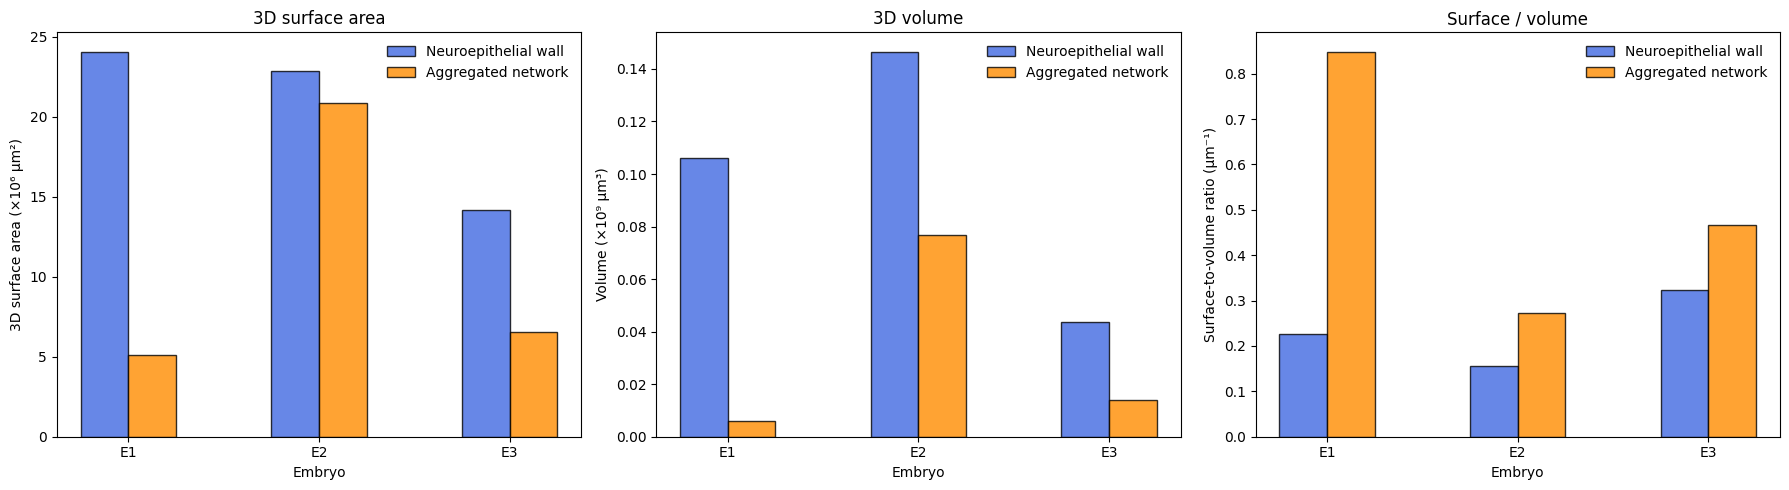

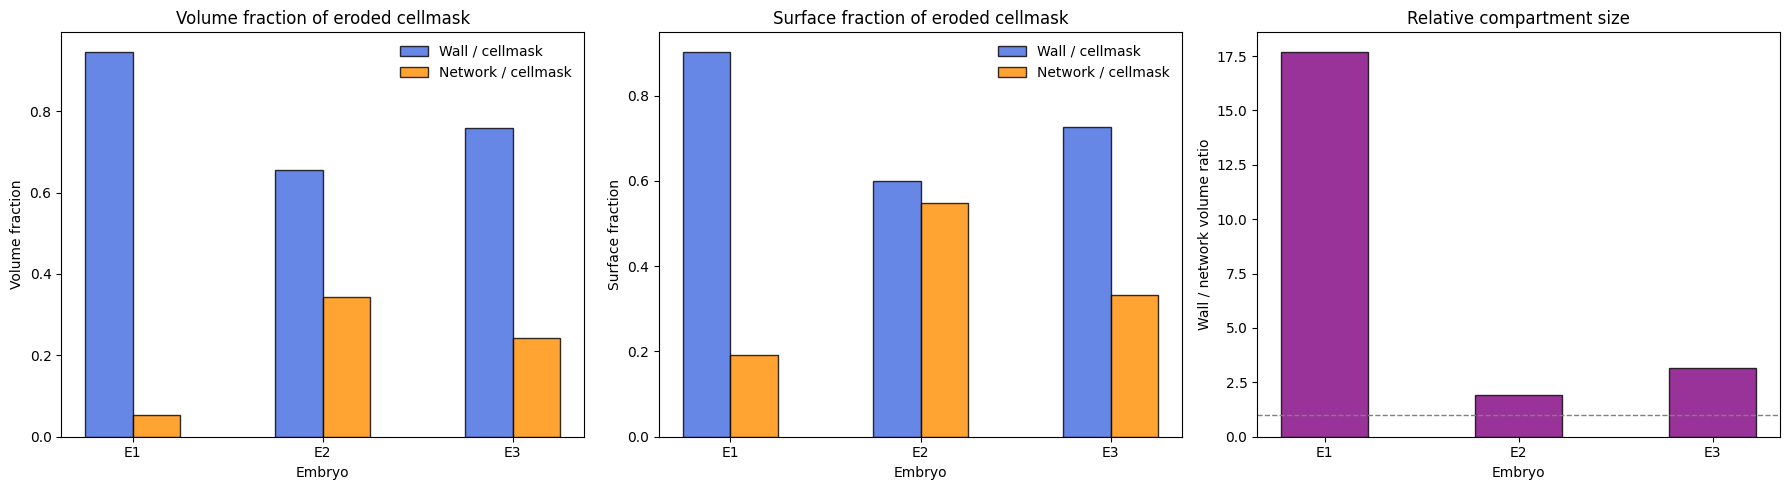

Saved absolute metrics figure:
/Users/fmaurelia/Library/CloudStorage/OneDrive-UniversitéClermontAuvergne/PHD/Github repository/demo results/quantification/neuroepithelial_wall_vs_aggregated_network_absolute_metrics.png
Saved fraction metrics figure:
/Users/fmaurelia/Library/CloudStorage/OneDrive-UniversitéClermontAuvergne/PHD/Github repository/demo results/quantification/neuroepithelial_wall_vs_aggregated_network_fraction_metrics.png


In [2]:
import os
import gc
import numpy as np
import pandas as pd
import tifffile as tiff
import matplotlib.pyplot as plt

# =========================================================
# PIXEL / VOXEL SIZE PER EMBRYO
# From original CZI metadata
# =========================================================
pixel_sizes = {
    "E1": {
        "x_um": 2.609890922263899,
        "y_um": 2.609890922263899,
        "z_um": 5.1878006546400135,
    },
    "E2": {
        "x_um": 2.606761966323059,
        "y_um": 2.606761966323059,
        "z_um": 5.957028609336942,
    },
    "E3": {
        "x_um": 2.606761966323059,
        "y_um": 2.606761966323059,
        "z_um": 5.957028609336942,
    },
}

# =========================================================
# PATHS
# =========================================================
BASE_DIR = "/Users/fmaurelia/Library/CloudStorage/OneDrive-UniversitéClermontAuvergne/PHD/Github repository"
seg_dir = os.path.join(BASE_DIR, "demo results")

out_dir = os.path.join(seg_dir, "quantification")
os.makedirs(out_dir, exist_ok=True)

csv_output = os.path.join(
    out_dir,
    "neuroepithelial_wall_vs_aggregated_network_metrics.csv"
)

absolute_metrics_path = os.path.join(
    out_dir,
    "neuroepithelial_wall_vs_aggregated_network_absolute_metrics.png"
)

fraction_metrics_path = os.path.join(
    out_dir,
    "neuroepithelial_wall_vs_aggregated_network_fraction_metrics.png"
)

# =========================================================
# INPUT FILES
# =========================================================
# IMPORTANT:
# If wall/network are biologically swapped in your visual QC,
# swap ONLY these two file assignments.
paths = {
    "E1": {
        "cellmask_eroded": os.path.join(seg_dir, "E1_cellmask_segmentation_thr065_eroded2_2D_blackSignal.tif"),
        "phallo": os.path.join(seg_dir, "E1_phalloidin_segmentation_thr08.tif"),
        "wall": os.path.join(seg_dir, "E1_neuroepithelial_wall_blackSignal.tif"),
        "network": os.path.join(seg_dir, "E1_aggregated_network_blackSignal.tif"),
    },
    "E2": {
        "cellmask_eroded": os.path.join(seg_dir, "E2_cellmask_segmentation_thr08_eroded2_2D_blackSignal.tif"),
        "phallo": os.path.join(seg_dir, "E2_phalloidin_segmentation_thr08.tif"),
        "wall": os.path.join(seg_dir, "E2_neuroepithelial_wall_blackSignal.tif"),
        "network": os.path.join(seg_dir, "E2_aggregated_network_blackSignal.tif"),
    },
    "E3": {
        "cellmask_eroded": os.path.join(seg_dir, "E3_cellmask_segmentation_thr08_eroded2_2D_blackSignal.tif"),
        "phallo": os.path.join(seg_dir, "E3_phalloidin_segmentation_thr08.tif"),
        "wall": os.path.join(seg_dir, "E3_neuroepithelial_wall_blackSignal.tif"),
        "network": os.path.join(seg_dir, "E3_aggregated_network_blackSignal.tif"),
    },
}

# =========================================================
# SIGNAL CONVENTIONS
# =========================================================
# Current demo outputs:
# cellmask_eroded -> signal BLACK
# wall            -> signal BLACK
# network         -> signal BLACK
# phallo          -> signal WHITE
signal_is_white_map = {
    "cellmask_eroded": False,
    "wall": False,
    "network": False,
    "phallo": True,
}

# =========================================================
# SURFACE CALCULATION DOWNSAMPLING IN XY
# =========================================================
ds_xy_surface = 2
print("Surface XY downsampling:", ds_xy_surface)

# =========================================================
# SIMPLE STACK READER FOR DEMO STACKS
# Forces arrays to (Z, Y, X)
# =========================================================
class StackReader:
    def __init__(self, path):
        self.path = path
        self.arr = np.squeeze(tiff.imread(path))

        print("\nOpening:")
        print(path)
        print("Raw loaded shape:", self.arr.shape)
        print("dtype:", self.arr.dtype)

        if self.arr.ndim == 2:
            self.arr = self.arr[np.newaxis, :, :]
        elif self.arr.ndim == 3:
            pass
        else:
            raise ValueError(f"Unsupported shape after squeeze: {self.arr.shape}")

        self.Z, self.Y, self.X = self.arr.shape

        print("Detected shape:", (self.Z, self.Y, self.X))
        print("Mode: in-memory 3D")

    def read_z(self, z):
        return self.arr[z]

    def close(self):
        pass

# =========================================================
# FOREGROUND LOGIC
# =========================================================
def get_signal_mask(img, signal_is_white=True):
    """
    Converts image to boolean signal mask.

    If signal_is_white=True:
        signal = img > 0

    If signal_is_white=False:
        signal = img == img.min()
    """
    if signal_is_white:
        return img > 0
    else:
        return img == img.min()

# =========================================================
# METRICS FUNCTION
# =========================================================
def compute_metrics_streaming(
    path,
    Z_use,
    pixel_x_um,
    pixel_y_um,
    pixel_z_um,
    signal_is_white=True,
    ds_xy_surface=2
):
    """
    Computes:
    - 3D voxel surface area in um2
    - volume in um3
    - projected area in um2
    """

    reader = StackReader(path)

    if Z_use > reader.Z:
        raise ValueError(f"Z_use={Z_use} larger than file Z={reader.Z}")

    voxel_volume_um3 = pixel_z_um * pixel_y_um * pixel_x_um
    pixel_area_um2 = pixel_y_um * pixel_x_um

    volume_voxels = 0
    projection = np.zeros((reader.Y, reader.X), dtype=bool)

    dz = pixel_z_um
    dy = pixel_y_um * ds_xy_surface
    dx = pixel_x_um * ds_xy_surface

    face_area_z = dy * dx
    face_area_y = dz * dx
    face_area_x = dz * dy

    surface_um2 = 0.0
    prev_ds = None

    for z in range(Z_use):

        img = reader.read_z(z)

        if img.ndim != 2:
            raise ValueError(
                f"read_z({z}) from {path} returned shape {img.shape}, expected 2D"
            )

        mask_full = get_signal_mask(
            img,
            signal_is_white=signal_is_white
        )

        volume_voxels += int(mask_full.sum())
        projection |= mask_full

        mask_ds = mask_full[::ds_xy_surface, ::ds_xy_surface]

        # Z-direction faces
        if prev_ds is None:
            surface_um2 += mask_ds.sum() * face_area_z
        else:
            surface_um2 += np.logical_xor(mask_ds, prev_ds).sum() * face_area_z

        # Y-direction faces
        surface_um2 += mask_ds[0, :].sum() * face_area_y
        surface_um2 += mask_ds[-1, :].sum() * face_area_y
        surface_um2 += np.logical_xor(mask_ds[1:, :], mask_ds[:-1, :]).sum() * face_area_y

        # X-direction faces
        surface_um2 += mask_ds[:, 0].sum() * face_area_x
        surface_um2 += mask_ds[:, -1].sum() * face_area_x
        surface_um2 += np.logical_xor(mask_ds[:, 1:], mask_ds[:, :-1]).sum() * face_area_x

        prev_ds = mask_ds

    if prev_ds is not None:
        surface_um2 += prev_ds.sum() * face_area_z

    volume_um3 = volume_voxels * voxel_volume_um3
    projected_area_um2 = projection.sum() * pixel_area_um2

    reader.close()

    return {
        "surface_um2": surface_um2,
        "volume_um3": volume_um3,
        "projected_area_um2": projected_area_um2,
        "surface_to_volume_um_minus1": surface_um2 / volume_um3 if volume_um3 > 0 else np.nan,
    }

# =========================================================
# RUN ANALYSIS
# =========================================================
results = []

for embryo, p in paths.items():

    print("\n===================================================")
    print("Processing embryo:", embryo)
    print("===================================================")

    px = pixel_sizes[embryo]["x_um"]
    py = pixel_sizes[embryo]["y_um"]
    pz = pixel_sizes[embryo]["z_um"]

    print("Pixel size X:", px)
    print("Pixel size Y:", py)
    print("Pixel size Z:", pz)

    # -----------------------------------------------------
    # Check dimensions and common Z
    # -----------------------------------------------------
    readers = {k: StackReader(v) for k, v in p.items()}

    XY_shapes = {(r.Y, r.X) for r in readers.values()}
    if len(XY_shapes) != 1:
        raise ValueError(f"XY mismatch for {embryo}: {XY_shapes}")

    Z_use = min(r.Z for r in readers.values())

    for key, r in readers.items():
        if r.Z != Z_use:
            print(f"WARNING: {embryo} {key} has Z={r.Z}, using Z_use={Z_use}")
        r.close()

    # -----------------------------------------------------
    # Compute metrics for each compartment
    # -----------------------------------------------------
    metrics = {}

    for compartment in ["cellmask_eroded", "phallo", "wall", "network"]:
        print(f"\nComputing metrics for {embryo} | {compartment} ...")

        metrics[compartment] = compute_metrics_streaming(
            p[compartment],
            Z_use=Z_use,
            pixel_x_um=px,
            pixel_y_um=py,
            pixel_z_um=pz,
            signal_is_white=signal_is_white_map[compartment],
            ds_xy_surface=ds_xy_surface
        )

        gc.collect()

    # -----------------------------------------------------
    # Derived fractions and ratios
    # -----------------------------------------------------
    wall_over_cellmask_volume = (
        metrics["wall"]["volume_um3"] / metrics["cellmask_eroded"]["volume_um3"]
        if metrics["cellmask_eroded"]["volume_um3"] > 0 else np.nan
    )

    network_over_cellmask_volume = (
        metrics["network"]["volume_um3"] / metrics["cellmask_eroded"]["volume_um3"]
        if metrics["cellmask_eroded"]["volume_um3"] > 0 else np.nan
    )

    wall_over_network_volume = (
        metrics["wall"]["volume_um3"] / metrics["network"]["volume_um3"]
        if metrics["network"]["volume_um3"] > 0 else np.nan
    )

    wall_over_cellmask_surface = (
        metrics["wall"]["surface_um2"] / metrics["cellmask_eroded"]["surface_um2"]
        if metrics["cellmask_eroded"]["surface_um2"] > 0 else np.nan
    )

    network_over_cellmask_surface = (
        metrics["network"]["surface_um2"] / metrics["cellmask_eroded"]["surface_um2"]
        if metrics["cellmask_eroded"]["surface_um2"] > 0 else np.nan
    )

    wall_over_network_surface = (
        metrics["wall"]["surface_um2"] / metrics["network"]["surface_um2"]
        if metrics["network"]["surface_um2"] > 0 else np.nan
    )

    results.append({
        "embryo": embryo,

        "pixel_x_um": px,
        "pixel_y_um": py,
        "pixel_z_um": pz,
        "Z_used": Z_use,
        "surface_ds_xy": ds_xy_surface,

        # cellmask eroded
        "cellmask_eroded_surface_um2": metrics["cellmask_eroded"]["surface_um2"],
        "cellmask_eroded_volume_um3": metrics["cellmask_eroded"]["volume_um3"],
        "cellmask_eroded_projected_area_um2": metrics["cellmask_eroded"]["projected_area_um2"],
        "cellmask_eroded_surface_to_volume_um_minus1": metrics["cellmask_eroded"]["surface_to_volume_um_minus1"],

        # phallo
        "phallo_surface_um2": metrics["phallo"]["surface_um2"],
        "phallo_volume_um3": metrics["phallo"]["volume_um3"],
        "phallo_projected_area_um2": metrics["phallo"]["projected_area_um2"],
        "phallo_surface_to_volume_um_minus1": metrics["phallo"]["surface_to_volume_um_minus1"],

        # wall
        "wall_surface_um2": metrics["wall"]["surface_um2"],
        "wall_volume_um3": metrics["wall"]["volume_um3"],
        "wall_projected_area_um2": metrics["wall"]["projected_area_um2"],
        "wall_surface_to_volume_um_minus1": metrics["wall"]["surface_to_volume_um_minus1"],

        # network
        "network_surface_um2": metrics["network"]["surface_um2"],
        "network_volume_um3": metrics["network"]["volume_um3"],
        "network_projected_area_um2": metrics["network"]["projected_area_um2"],
        "network_surface_to_volume_um_minus1": metrics["network"]["surface_to_volume_um_minus1"],

        # derived fractions
        "wall_over_cellmask_volume": wall_over_cellmask_volume,
        "network_over_cellmask_volume": network_over_cellmask_volume,
        "wall_over_network_volume": wall_over_network_volume,

        "wall_over_cellmask_surface": wall_over_cellmask_surface,
        "network_over_cellmask_surface": network_over_cellmask_surface,
        "wall_over_network_surface": wall_over_network_surface,
    })

    print("\nDone:", embryo)
    print("Wall / cellmask volume:", wall_over_cellmask_volume)
    print("Network / cellmask volume:", network_over_cellmask_volume)
    print("Wall / network volume:", wall_over_network_volume)

# =========================================================
# SAVE CSV
# =========================================================
df = pd.DataFrame(results)

try:
    display(df)
except NameError:
    print(df)

df.to_csv(csv_output, index=False)

print("Saved CSV:")
print(csv_output)

# =========================================================
# PLOTS
# =========================================================
df_plot = df.copy()

embryo_order = ["E1", "E2", "E3"]
df_plot["embryo"] = pd.Categorical(
    df_plot["embryo"],
    categories=embryo_order,
    ordered=True
)
df_plot = df_plot.sort_values("embryo").reset_index(drop=True)

embryos = df_plot["embryo"].astype(str).values
x = np.arange(len(embryos))
width = 0.25

surface_scale = 1e6
volume_scale = 1e9

# =========================================================
# FIGURE 1: ABSOLUTE WALL vs NETWORK
# =========================================================
fig_abs, axes = plt.subplots(1, 3, figsize=(18, 5))

# Surface
ax = axes[0]
wall_surface = df_plot["wall_surface_um2"].values / surface_scale
network_surface = df_plot["network_surface_um2"].values / surface_scale

ax.bar(
    x - width/2,
    wall_surface,
    width,
    label="Neuroepithelial wall",
    color="royalblue",
    edgecolor="black",
    alpha=0.8
)

ax.bar(
    x + width/2,
    network_surface,
    width,
    label="Aggregated network",
    color="darkorange",
    edgecolor="black",
    alpha=0.8
)

ax.set_xticks(x)
ax.set_xticklabels(embryos)
ax.set_ylabel("3D surface area (×10⁶ µm²)")
ax.set_xlabel("Embryo")
ax.set_title("3D surface area")
ax.legend(frameon=False)

# Volume
ax = axes[1]
wall_volume = df_plot["wall_volume_um3"].values / volume_scale
network_volume = df_plot["network_volume_um3"].values / volume_scale

ax.bar(
    x - width/2,
    wall_volume,
    width,
    label="Neuroepithelial wall",
    color="royalblue",
    edgecolor="black",
    alpha=0.8
)

ax.bar(
    x + width/2,
    network_volume,
    width,
    label="Aggregated network",
    color="darkorange",
    edgecolor="black",
    alpha=0.8
)

ax.set_xticks(x)
ax.set_xticklabels(embryos)
ax.set_ylabel("Volume (×10⁹ µm³)")
ax.set_xlabel("Embryo")
ax.set_title("3D volume")
ax.legend(frameon=False)

# Surface-to-volume
ax = axes[2]
wall_sv = df_plot["wall_surface_to_volume_um_minus1"].values
network_sv = df_plot["network_surface_to_volume_um_minus1"].values

ax.bar(
    x - width/2,
    wall_sv,
    width,
    label="Neuroepithelial wall",
    color="royalblue",
    edgecolor="black",
    alpha=0.8
)

ax.bar(
    x + width/2,
    network_sv,
    width,
    label="Aggregated network",
    color="darkorange",
    edgecolor="black",
    alpha=0.8
)

ax.set_xticks(x)
ax.set_xticklabels(embryos)
ax.set_ylabel("Surface-to-volume ratio (µm⁻¹)")
ax.set_xlabel("Embryo")
ax.set_title("Surface / volume")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

# =========================================================
# FIGURE 2: FRACTIONS / RATIOS
# =========================================================
fig_frac, axes = plt.subplots(1, 3, figsize=(18, 5))

# Wall vs cellmask volume fraction
ax = axes[0]
ax.bar(
    x - width/2,
    df_plot["wall_over_cellmask_volume"].values,
    width,
    label="Wall / cellmask",
    color="royalblue",
    edgecolor="black",
    alpha=0.8
)
ax.bar(
    x + width/2,
    df_plot["network_over_cellmask_volume"].values,
    width,
    label="Network / cellmask",
    color="darkorange",
    edgecolor="black",
    alpha=0.8
)
ax.set_xticks(x)
ax.set_xticklabels(embryos)
ax.set_ylabel("Volume fraction")
ax.set_xlabel("Embryo")
ax.set_title("Volume fraction of eroded cellmask")
ax.legend(frameon=False)

# Wall vs cellmask surface fraction
ax = axes[1]
ax.bar(
    x - width/2,
    df_plot["wall_over_cellmask_surface"].values,
    width,
    label="Wall / cellmask",
    color="royalblue",
    edgecolor="black",
    alpha=0.8
)
ax.bar(
    x + width/2,
    df_plot["network_over_cellmask_surface"].values,
    width,
    label="Network / cellmask",
    color="darkorange",
    edgecolor="black",
    alpha=0.8
)
ax.set_xticks(x)
ax.set_xticklabels(embryos)
ax.set_ylabel("Surface fraction")
ax.set_xlabel("Embryo")
ax.set_title("Surface fraction of eroded cellmask")
ax.legend(frameon=False)

# Wall / network ratio
ax = axes[2]
ax.bar(
    x,
    df_plot["wall_over_network_volume"].values,
    width=0.45,
    color="purple",
    edgecolor="black",
    alpha=0.8
)
ax.axhline(1, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(embryos)
ax.set_ylabel("Wall / network volume ratio")
ax.set_xlabel("Embryo")
ax.set_title("Relative compartment size")

plt.tight_layout()
plt.show()

# =========================================================
# SAVE FIGURES
# =========================================================
fig_abs.savefig(
    absolute_metrics_path,
    dpi=600,
    bbox_inches="tight",
    transparent=False
)

fig_frac.savefig(
    fraction_metrics_path,
    dpi=600,
    bbox_inches="tight",
    transparent=False
)

print("Saved absolute metrics figure:")
print(absolute_metrics_path)

print("Saved fraction metrics figure:")
print(fraction_metrics_path)